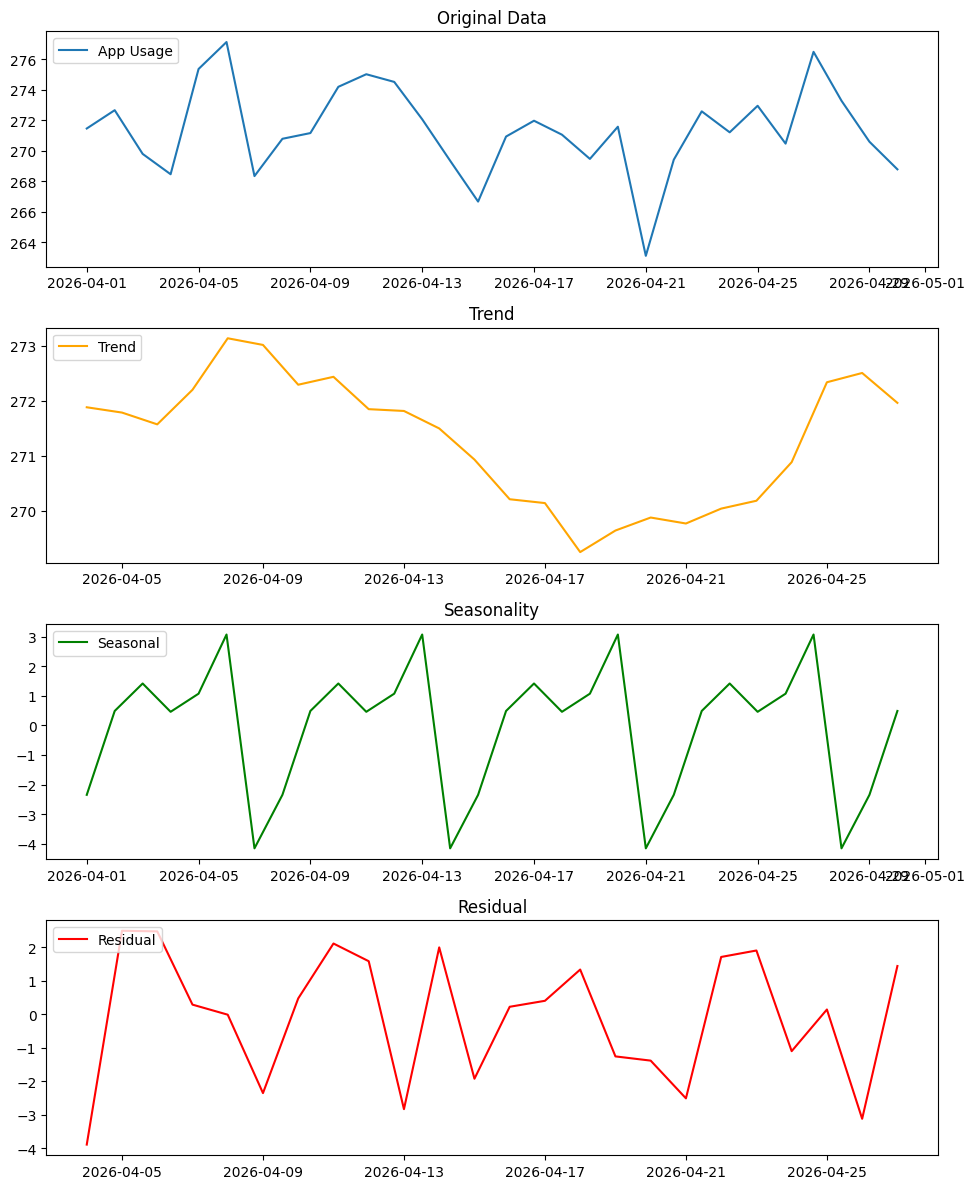

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


data = pd.read_csv("user_behavior_timeseries.csv")
data.columns = data.columns.str.strip()

# Convert Date column
data['Date'] = pd.to_datetime(data['Date'])

# Set index
data.set_index('Date', inplace=True)


data = data.groupby('Date').mean(numeric_only=True)

# Select column
col = "App Usage Time"

data[col] = data[col] + np.random.normal(0, 3, len(data))


decomposition = seasonal_decompose(data[col], model='additive', period=7)


plt.figure(figsize=(10,12))

# Original
plt.subplot(411)
plt.plot(data[col], label='App Usage')
plt.legend(loc='upper left')
plt.title('Original Data')

# Trend
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.title('Trend')

# Seasonal
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.title('Seasonality')

# Residual
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='red')
plt.legend(loc='upper left')
plt.title('Residual')

plt.tight_layout()
plt.show()